# Required packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
import statsmodels.api as sm
from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.diagnostic import acorr_ljungbox

In [3]:
from itertools import product
from typing import Union
from tqdm.notebook import tqdm, trange
import warnings

# Exercise 1

### 1

In [4]:
macro_data = sm.datasets.macrodata.load_pandas()

In [5]:
macro_econ = macro_data['data']

In [6]:
endog = macro_econ[['realdpi', 'realcons']].diff().dropna()

## 2

In [7]:
orderlist = list(product(
    range(4), range(4)
))

In [8]:
orderlist[:4]

[(0, 0), (0, 1), (0, 2), (0, 3)]

In [9]:
len(orderlist)

16

## 3

In [10]:
def optimize_VARMA(endog: pd.DataFrame, order_list: Union[list, tuple, pd.Series]) -> pd.DataFrame:
    """
    Find the optimum value of p using AIC.

    Params:
    --------
    endog: pd.DataFrame
        A dataframe with numerical columns.
    order_list: Union[list, tuple, pd.Series]
        List-like order with values of p and q.

    Returns:
    --------
        A pd.DataFrame object with p and AIC.
    """
    results = []

    for order in tqdm(order_list):
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                model = VARMAX(endog, order=order).fit(disp=False)
                results.append([*order, model.aic])
        except:
            continue

    return pd.DataFrame(results, columns=['p', 'q', 'AIC']).sort_values(by='AIC', ascending=True).reset_index(drop=True)
            

## 4

In [11]:
df_aic_varma = optimize_VARMA(endog, orderlist)

  0%|          | 0/16 [00:00<?, ?it/s]

In [12]:
df_aic_varma

,p,q,AIC
0,0,3,4045.367324
1,3,0,4046.807496
2,1,1,4048.629901
3,3,3,4049.215800
4,2,3,4050.462608
5,3,1,4050.779890
6,2,1,4052.164902
7,1,3,4052.864948
8,2,2,4053.157497
9,1,2,4054.208353


In [13]:
grangercausalitytests(endog.iloc[:, [0,1]],[1])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=34.8599 , p=0.0000  , df_denom=198, df_num=1
ssr based chi2 test:   chi2=35.3881 , p=0.0000  , df=1
likelihood ratio test: chi2=32.5962 , p=0.0000  , df=1
parameter F test:         F=34.8599 , p=0.0000  , df_denom=198, df_num=1


{np.int64(1): ({'ssr_ftest': (np.float64(34.85993021746469),
    np.float64(1.5182640983841195e-08),
    np.float64(198.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(35.38811097833537),
    np.float64(2.701307643226952e-09),
    np.int64(1)),
   'lrtest': (np.float64(32.59618693191169),
    np.float64(1.1343708157482829e-08),
    np.int64(1)),
   'params_ftest': (np.float64(34.85993021746473),
    np.float64(1.5182640983840976e-08),
    np.float64(198.0),
    1.0)},
   array([[0., 1., 0.]])])}

In [14]:
grangercausalitytests(endog.iloc[:, [1,0]],[1])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=7.7368  , p=0.0059  , df_denom=198, df_num=1
ssr based chi2 test:   chi2=7.8540  , p=0.0051  , df=1
likelihood ratio test: chi2=7.7045  , p=0.0055  , df=1
parameter F test:         F=7.7368  , p=0.0059  , df_denom=198, df_num=1


{np.int64(1): ({'ssr_ftest': (np.float64(7.736820522495765),
    np.float64(0.005933432489039575),
    np.float64(198.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(7.854045075866912),
    np.float64(0.005070712747425036),
    np.int64(1)),
   'lrtest': (np.float64(7.7044809564763455),
    np.float64(0.005508391012750673),
    np.int64(1)),
   'params_ftest': (np.float64(7.736820522495727),
    np.float64(0.005933432489039689),
    np.float64(198.0),
    1.0)},
   array([[0., 1., 0.]])])}

In [15]:
model = VARMAX(endog, order=(1,1)).fit()

/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [16]:
print(model.summary())

                              Statespace Model Results                             
Dep. Variable:     ['realdpi', 'realcons']   No. Observations:                  202
Model:                          VARMA(1,1)   Log Likelihood               -2011.315
                               + intercept   AIC                           4048.630
Date:                     Tue, 16 Jun 2026   BIC                           4091.637
Time:                             09:30:03   HQIC                          4066.031
Sample:                                  0                                         
                                     - 202                                         
Covariance Type:                       opg                                         
Ljung-Box (L1) (Q):             0.09, 0.09   Jarque-Bera (JB):          58.97, 4.37
Prob(Q):                        0.77, 0.77   Prob(JB):                   0.00, 0.11
Heteroskedasticity (H):         4.59, 2.84   Skew:                      0.33

## 5

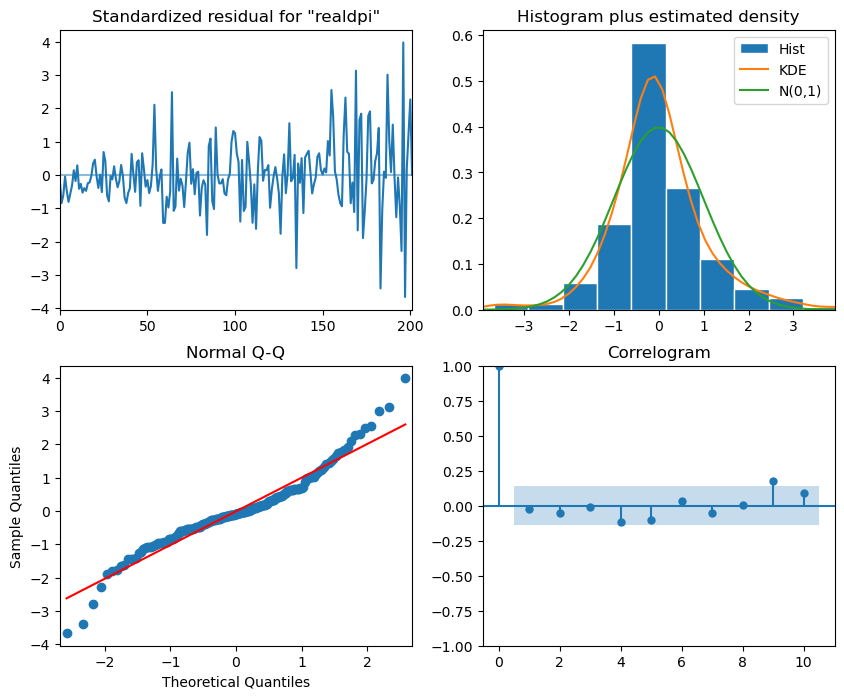

In [17]:
model.plot_diagnostics(figsize=(10,8), variable=0);

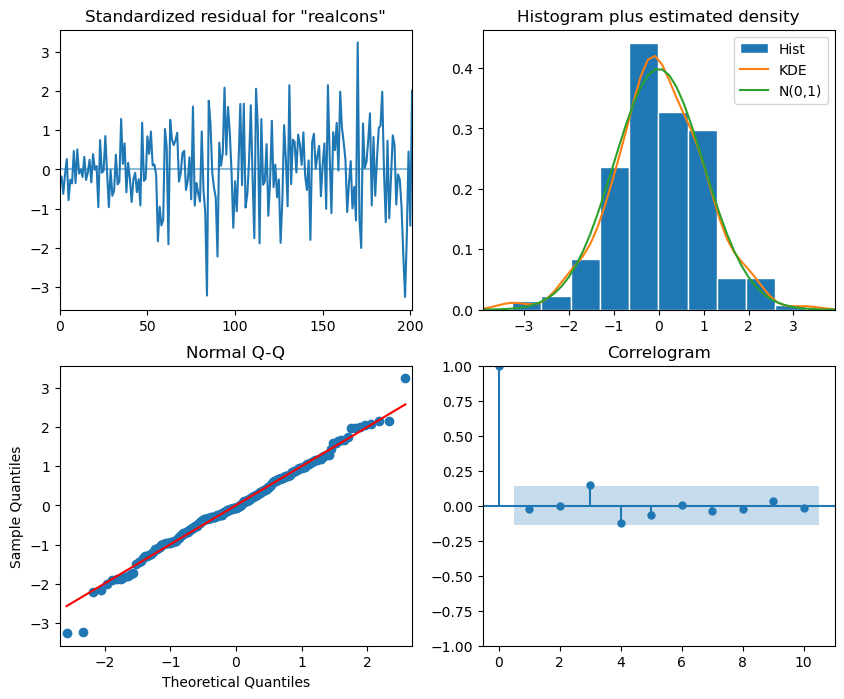

In [18]:
model.plot_diagnostics(figsize=(10,8), variable=1);

## 6

In [19]:
def rolling_forecast(data: pd.DataFrame, train_len: int, horizon: int, window: int,
                    method: str, order: Union[tuple, list] = (1, 1)) -> pd.DataFrame:
    """
    Rolling forecast for VAR model.

    Params:
    -------
    data: pd.DataFrame
        DataFrame with target time series.
    train_len: int
        Train size.
    horizon: int,
        Numbers of steps ahead to be predicted.
    window: int,
        Number of steps to be predicted at each iteration.
    method: str
        Method used to make the predictions. Must be 'var' (for VAR model) or 'last' (for last value baseline model).

    Returns:
    --------
        A dataframe with horizon rows and the same number of columns of data.
    """

    if method not in ('var', 'last'):
        raise ValueError('method must be or "var" either "last".')

    total_len = train_len + horizon

    realdpi = []
    realcons = []
    
    if method == 'var':
        for i in trange(train_len, total_len, window, desc='var'):
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore')
                    model = VARMAX(data[:i], order=order).fit(disp=False)
                    predictions = model.get_prediction(0, i + window - 1)
                    realdpi.extend(predictions.predicted_mean.iloc[-window:].loc[:, 'realdpi'].values)
                    realcons.extend(predictions.predicted_mean.iloc[-window:].loc[:, 'realcons'].values)
            except:
                continue
    elif method == 'last':
        for i in trange(train_len, total_len, window, desc='last'):
            realdpi.extend(data[:i].iloc[-1].loc['realdpi'] for _ in range(window))
            realcons.extend(data[:i].iloc[-1].loc['realcons'] for _ in range(window))

    return pd.DataFrame({
        'realdpi_pred': realdpi,
        'realdpi_true': data.loc[train_len:, 'realdpi'],
        'realcons_pred': realcons,
        'realcons_true': data.loc[train_len:, 'realcons'],
    }, index=data.index[train_len:])
            

In [20]:
train = endog[:162]
test = endog[162:]

In [21]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 4
df_pred_var = rolling_forecast(
    endog, TRAIN_LEN, HORIZON, WINDOW, 'var' 
)

var:   0%|          | 0/10 [00:00<?, ?it/s]

In [22]:
df_pred_var.head()

,realdpi_pred,realdpi_true,realcons_pred,realcons_true
163,57.351073,121.8,69.682766,102.8
164,59.677261,165.7,68.851513,112.1
165,57.062695,82.5,66.847688,70.5
166,56.787626,86.4,65.508178,74.1
167,63.945831,12.3,74.935341,67.6


In [23]:
df_pred_last = rolling_forecast(
    endog, TRAIN_LEN, HORIZON, WINDOW, 'last'
)

last:   0%|          | 0/10 [00:00<?, ?it/s]

In [24]:
df_pred_last.head()

,realdpi_pred,realdpi_true,realcons_pred,realcons_true
163,49.9,121.8,86.5,102.8
164,49.9,165.7,86.5,112.1
165,49.9,82.5,86.5,70.5
166,49.9,86.4,86.5,74.1
167,86.4,12.3,74.1,67.6


In [25]:
integration = lambda pred, initial_value: initial_value + np.cumsum(pred)

In [26]:
df_pred_integrated = pd.DataFrame({
    'pred_last_realcons': integration(df_pred_last['realcons_pred'], macro_econ.loc[162, 'realcons']),
    'pred_var_realcons': integration(df_pred_var['realcons_pred'], macro_econ.loc[162, 'realcons']),
    'realcons': integration(test['realcons'], macro_econ.loc[162, 'realcons']),
    'pred_last_realdpi': integration(df_pred_last['realdpi_pred'], macro_econ.loc[162, 'realdpi']),
    'pred_var_realdpi': integration(df_pred_var['realdpi_pred'], macro_econ.loc[162, 'realdpi']),
    'realdpi': integration(test['realdpi'], macro_econ.loc[162, 'realdpi']),
})

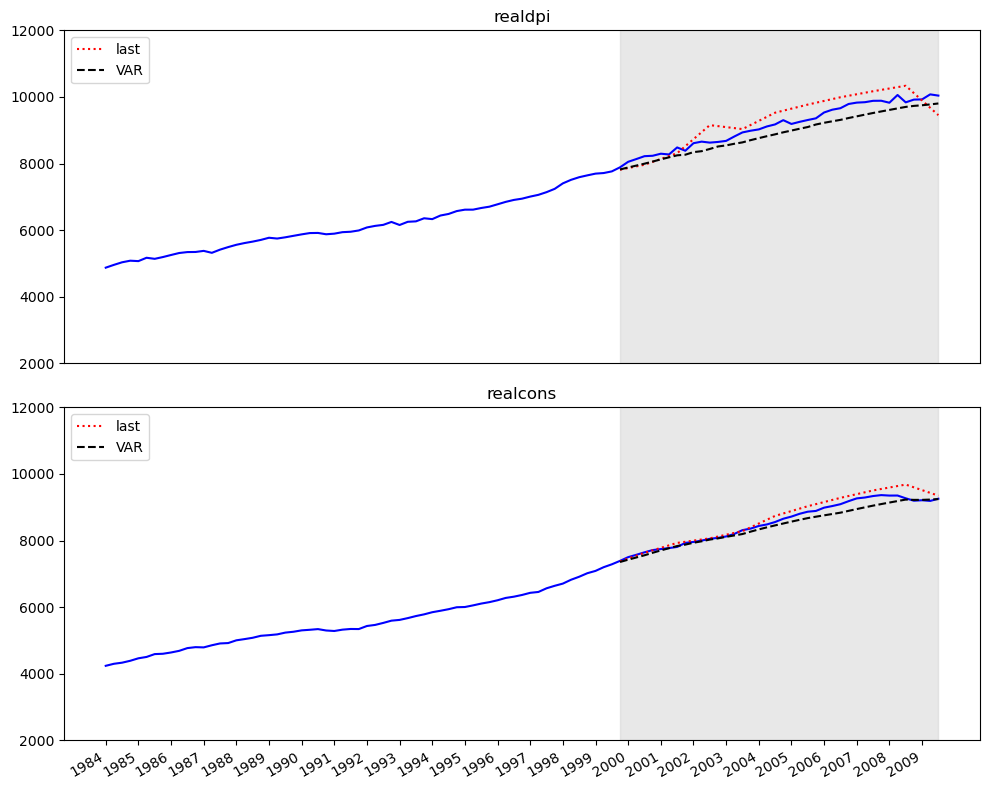

In [27]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10,8), sharex=True)
ax[0].plot(macro_econ.loc[100:, 'realdpi'], 'b-')
ax[0].plot(df_pred_integrated['pred_last_realdpi'], 'r:', label='last')
ax[0].plot(df_pred_integrated['pred_var_realdpi'], 'k--', label='VAR')
ax[0].axvspan(df_pred_integrated.index[0], df_pred_integrated.index[-1], color='lightgray', alpha=0.5)
ax[0].xaxis.set_ticks_position('none')
ax[0].set_title('realdpi')
ax[0].legend(loc='upper left')
ax[0].set_ylim([2000, 12000])

ax[1].plot(macro_econ.loc[100:, 'realcons'], 'b-')
ax[1].plot(df_pred_integrated['pred_last_realcons'], 'r:', label='last')
ax[1].plot(df_pred_integrated['pred_var_realcons'], 'k--', label='VAR')
ax[1].axvspan(df_pred_integrated.index[0], df_pred_integrated.index[-1], color='lightgray', alpha=0.5)
ax[1].set_title('realcons')
ax[1].set_ylim([2000, 12000])
ax[1].legend(loc='upper left')
ax[1].set_xticks(macro_econ.index[100::4])
ax[1].set_xticklabels(macro_data['data'].loc[100::4, 'year'].astype(np.int64))

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 7

In [28]:
mape = lambda y, p: 100 * np.mean(np.abs((y - p) / y))

In [29]:
mape_realdpi = pd.Series({
    'last': mape(df_pred_integrated['realdpi'], df_pred_integrated['pred_last_realdpi']),
    'VAR':  mape(df_pred_integrated['realdpi'], df_pred_integrated['pred_var_realdpi'])
})
mape_realcons = pd.Series({
    'last': mape(df_pred_integrated['realcons'], df_pred_integrated['pred_last_realcons']),
    'VAR': mape(df_pred_integrated['realcons'],df_pred_integrated['pred_var_realcons'])
})

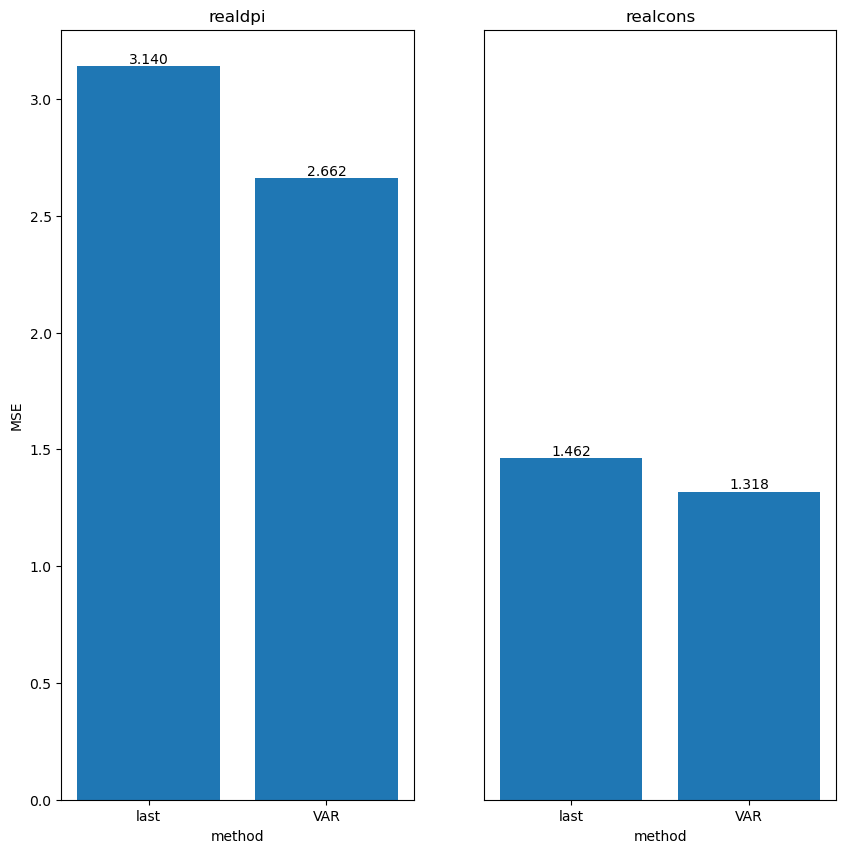

In [30]:
fig, ax = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10,10))
bars = ax[0].bar(mape_realdpi.index, mape_realdpi.values)
ax[0].bar_label(bars, fmt='%.3f')
ax[0].set_title('realdpi')
ax[0].set_xlabel('method')
ax[0].set_ylabel('MSE')

bars = ax[1].bar(mape_realcons.index, mape_realcons.values)
ax[1].bar_label(bars, fmt='%.3f')
ax[1].set_title('realcons')
ax[1].set_xlabel('method')
ax[1].yaxis.set_ticks_position('none')
ax[1].set_title('realcons')

plt.show()

# Exercise 2

## removing realdpi, realcons, year and quarter

In [31]:
exog_cols = macro_econ.columns.drop(['year', 'quarter', 'realdpi', 'realcons'])

In [32]:
exog_cols

Index(['realgdp', 'realinv', 'realgovt', 'cpi', 'm1', 'tbilrate', 'unemp',
       'pop', 'infl', 'realint'],
      dtype='str')

In [33]:
exog = macro_econ.loc[1:, exog_cols]

In [34]:
exog.head()

,realgdp,realinv,realgovt,cpi,m1,tbilrate,unemp,pop,infl,realint
1,2778.801,310.859,481.301,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,2775.488,289.226,491.260,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,2785.204,299.356,484.052,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,2847.699,331.722,462.199,29.54,139.6,3.50,5.2,180.007,2.31,1.19
5,2834.390,298.152,460.400,29.55,140.2,2.68,5.2,180.671,0.14,2.55


## 3

In [35]:
def optimize_VARMAX(endog: pd.DataFrame, exog: pd.DataFrame, order_list: Union[list, tuple, pd.Series]) -> pd.DataFrame:
    """
    Find the optimum value of p using AIC.

    Params:
    --------
    endog: pd.DataFrame
        A dataframe with numerical columns (target variables).
    exog: pd.DataFrame
        A dataframe with numerical columns (exogenous variables).
    order_list: Union[list, tuple, pd.Series]
        List-like order with values of p and q.

    Returns:
    --------
        A pd.DataFrame object with p and AIC.
    """
    results = []

    for order in tqdm(order_list):
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                model = VARMAX(endog, exog=exog, order=order).fit(disp=False)
                results.append([*order, model.aic])
        except:
            continue

    return pd.DataFrame(results, columns=['p', 'q', 'AIC']).sort_values(by='AIC', ascending=True).reset_index(drop=True)
            

In [36]:
df_aic_varmax = optimize_VARMAX(endog.iloc[:162], exog.iloc[:162], orderlist)

  0%|          | 0/16 [00:00<?, ?it/s]

In [37]:
df_aic_varmax

,p,q,AIC
0,1,0,3113.478554
1,0,1,3117.326716
2,2,0,3117.855527
3,1,1,3119.158962
4,3,0,3121.521262
5,0,3,3122.398471
6,0,2,3122.995277
7,1,2,3125.713735
8,1,3,3126.777265
9,2,1,3126.805587


## 4

In [73]:
grangercausalitytests(endog.iloc[:, [0,1]], [3])


Granger Causality
number of lags (no zero) 3
ssr based F test:         F=9.2363  , p=0.0000  , df_denom=192, df_num=3
ssr based chi2 test:   chi2=28.7191 , p=0.0000  , df=3
likelihood ratio test: chi2=26.8268 , p=0.0000  , df=3
parameter F test:         F=9.2363  , p=0.0000  , df_denom=192, df_num=3


{np.int64(3): ({'ssr_ftest': (np.float64(9.236302935003344),
    np.float64(9.771659881004587e-06),
    np.float64(192.0),
    np.int64(3)),
   'ssr_chi2test': (np.float64(28.719129438526025),
    np.float64(2.565354241450447e-06),
    np.int64(3)),
   'lrtest': (np.float64(26.826823124426937),
    np.float64(6.400614700874191e-06),
    np.int64(3)),
   'params_ftest': (np.float64(9.236302935003335),
    np.float64(9.771659881004702e-06),
    np.float64(192.0),
    3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
          [0., 0., 0., 0., 0., 1., 0.]])])}

In [74]:
grangercausalitytests(endog.iloc[:, [1, 0]], [3])


Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.8181  , p=0.0403  , df_denom=192, df_num=3
ssr based chi2 test:   chi2=8.7625  , p=0.0326  , df=3
likelihood ratio test: chi2=8.5751  , p=0.0355  , df=3
parameter F test:         F=2.8181  , p=0.0403  , df_denom=192, df_num=3


{np.int64(3): ({'ssr_ftest': (np.float64(2.8180926920793072),
    np.float64(0.04029520008929368),
    np.float64(192.0),
    np.int64(3)),
   'ssr_chi2test': (np.float64(8.762506964434095),
    np.float64(0.03262095244932233),
    np.int64(3)),
   'lrtest': (np.float64(8.575071029579703),
    np.float64(0.03550803145041808),
    np.int64(3)),
   'params_ftest': (np.float64(2.8180926920793166),
    np.float64(0.040295200089293166),
    np.float64(192.0),
    3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
          [0., 0., 0., 0., 0., 1., 0.]])])}

## 5

In [75]:
model = VARMAX(train, exog=exog.iloc[:162], order=(3, 0)).fit(disp=False)

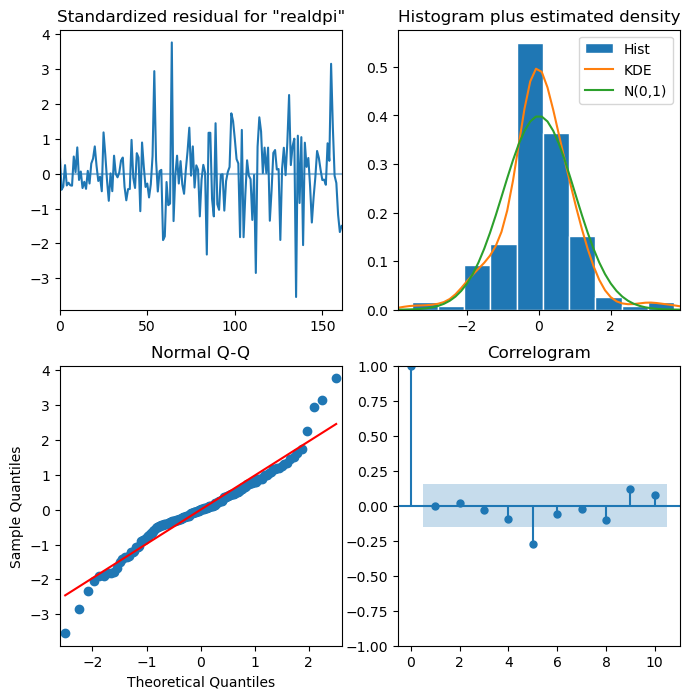

In [76]:
model.plot_diagnostics(figsize=(8, 8), variable=0);

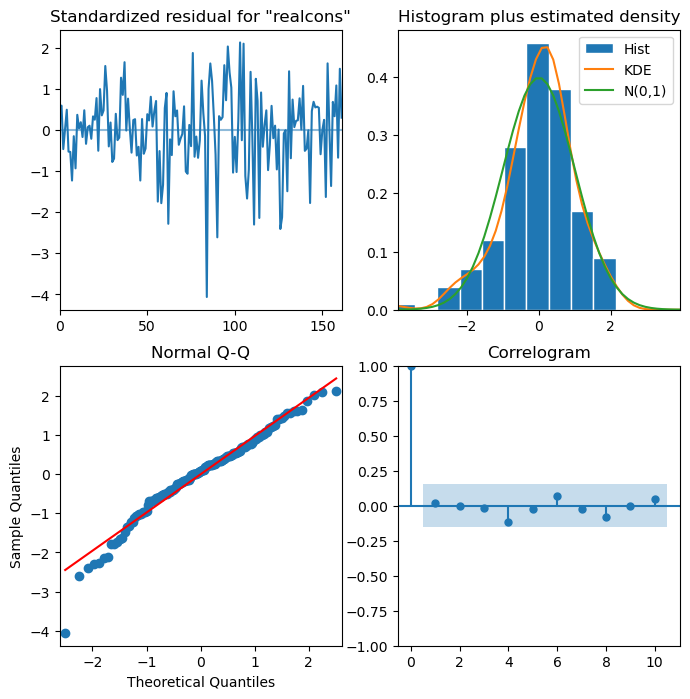

In [77]:
model.plot_diagnostics(figsize=(8, 8), variable=1);

In [78]:
residuals = model.resid

In [79]:
residuals

,realdpi,realcons
1,20.603967,16.794350
2,-16.152343,8.986024
3,-12.806627,-13.266012
4,8.372887,2.171740
5,-11.539515,8.055628
...,...,...
158,-2.046901,6.841505
159,-9.130760,21.413661
160,-40.167362,-23.876752
161,-57.158573,19.051340


In [80]:
acorr_ljungbox(residuals.iloc[:, 0])

,lb_stat,lb_pvalue
1,0.002635,0.959060
2,0.059565,0.970657
3,0.199724,0.977634
4,1.811534,0.770371
5,14.229365,0.014216
6,14.762148,0.022190
7,14.832359,0.038209
8,16.649301,0.033975
9,19.096912,0.024381
10,20.116310,0.028172


In [81]:
acorr_ljungbox(residuals.iloc[:, 1])

,lb_stat,lb_pvalue
1,0.135624,0.712671
2,0.136278,0.934131
3,0.147440,0.985592
4,1.610534,0.806898
5,2.294967,0.807006
6,3.140771,0.790983
7,3.283531,0.857594
8,6.074947,0.638837
9,6.078138,0.732073
10,6.332494,0.786598


## 6

In [95]:
def rolling_forecast(endog: pd.DataFrame, exog: pd.DataFrame, train_len: int, horizon: int, window: int,
                    method: str, order: Union[tuple, list] = (3, 0)) -> pd.DataFrame:
    """
    Rolling forecast for VAR model.

    Params:
    -------
    endog: pd.DataFrame
        DataFrame with target time series.
    exog: pd.DataFrame
        DataFrame with exogenous time series.
    train_len: int
        Train size.
    horizon: int,
        Numbers of steps ahead to be predicted.
    window: int,
        Number of steps to be predicted at each iteration.
    method: str
        Method used to make the predictions. Must be 'var' (for VAR model) or 'last' (for last value baseline model).

    Returns:
    --------
        A dataframe with horizon rows and the same number of columns of data.
    """

    if method not in ('var', 'last'):
        raise ValueError('method must be or "var" either "last".')

    total_len = train_len + horizon

    realdpi = []
    realcons = []
    
    if method == 'var':
        for i in trange(train_len, total_len, window, desc='var'):
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore')
                    model = VARMAX(endog[:i], exog[:i], order=order).fit(disp=False)
                    predictions = model.get_prediction(0, i + window - 1, exog=exog.iloc[-1])
                    realdpi.extend(predictions.predicted_mean.iloc[-window:].loc[:, 'realdpi'].values)
                    realcons.extend(predictions.predicted_mean.iloc[-window:].loc[:, 'realcons'].values)
            except:
                continue
    elif method == 'last':
        for i in trange(train_len, total_len, window, desc='last'):
            realdpi.extend(endog[:i].iloc[-1].loc['realdpi'] for _ in range(window))
            realcons.extend(endog[:i].iloc[-1].loc['realcons'] for _ in range(window))

    return pd.DataFrame({
        'realdpi_pred': realdpi,
        'realdpi_true': endog.loc[train_len:, 'realdpi'],
        'realcons_pred': realcons,
        'realcons_true': endog.loc[train_len:, 'realcons'],
    }, index=endog.index[train_len:])
            

In [91]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 1
df_pred_var = rolling_forecast(
    endog, exog, TRAIN_LEN, HORIZON, WINDOW, 'var' 
)

var:   0%|          | 0/40 [00:00<?, ?it/s]

len(realdpi)=40 | len(realcons)=40


In [93]:
df_pred_var.head()

,realdpi_pred,realdpi_true,realcons_pred,realcons_true
163,19.191732,121.8,122.920799,102.8
164,40.320740,165.7,136.090562,112.1
165,43.308035,82.5,136.747295,70.5
166,33.268982,86.4,126.712687,74.1
167,39.725159,12.3,127.410777,67.6


In [94]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 1
df_pred_last = rolling_forecast(
    endog, exog, TRAIN_LEN, HORIZON, WINDOW, 'last' 
)

last:   0%|          | 0/40 [00:00<?, ?it/s]

len(realdpi)=40 | len(realcons)=40


In [96]:
df_pred_last.head()

,realdpi_pred,realdpi_true,realcons_pred,realcons_true
163,49.9,121.8,86.5,102.8
164,121.8,165.7,102.8,112.1
165,165.7,82.5,112.1,70.5
166,82.5,86.4,70.5,74.1
167,86.4,12.3,74.1,67.6


## integration

In [97]:
integration = lambda pred, initial_value: initial_value + np.cumsum(pred)

In [98]:
df_pred_integrated = pd.DataFrame({
    'pred_last_realcons': integration(df_pred_last['realcons_pred'], macro_econ.loc[162, 'realcons']),
    'pred_var_realcons': integration(df_pred_var['realcons_pred'], macro_econ.loc[162, 'realcons']),
    'realcons': integration(test['realcons'], macro_econ.loc[162, 'realcons']),
    'pred_last_realdpi': integration(df_pred_last['realdpi_pred'], macro_econ.loc[162, 'realdpi']),
    'pred_var_realdpi': integration(df_pred_var['realdpi_pred'], macro_econ.loc[162, 'realdpi']),
    'realdpi': integration(test['realdpi'], macro_econ.loc[162, 'realdpi']),
})

In [99]:
df_pred_integrated.head()

,pred_last_realcons,pred_var_realcons,realcons,pred_last_realdpi,pred_var_realdpi,realdpi
163,7372.9,7409.320799,7389.2,7815.8,7785.091732,7887.7
164,7475.7,7545.411361,7501.3,7937.6,7825.412472,8053.4
165,7587.8,7682.158656,7571.8,8103.3,7868.720507,8135.9
166,7658.3,7808.871343,7645.9,8185.8,7901.989489,8222.3
167,7732.4,7936.282120,7713.5,8272.2,7941.714648,8234.6


## plotting forecasts

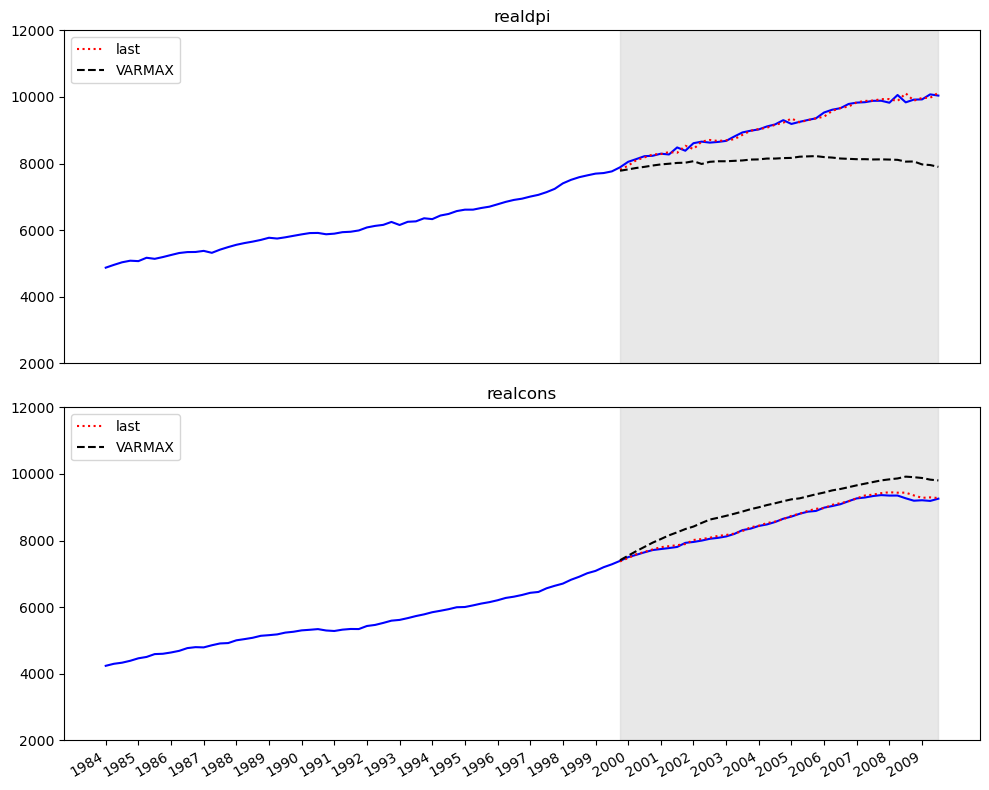

In [101]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10,8), sharex=True)
ax[0].plot(macro_econ.loc[100:, 'realdpi'], 'b-')
ax[0].plot(df_pred_integrated['pred_last_realdpi'], 'r:', label='last')
ax[0].plot(df_pred_integrated['pred_var_realdpi'], 'k--', label='VARMAX')
ax[0].axvspan(df_pred_integrated.index[0], df_pred_integrated.index[-1], color='lightgray', alpha=0.5)
ax[0].xaxis.set_ticks_position('none')
ax[0].set_title('realdpi')
ax[0].legend(loc='upper left')
ax[0].set_ylim([2000, 12000])

ax[1].plot(macro_econ.loc[100:, 'realcons'], 'b-')
ax[1].plot(df_pred_integrated['pred_last_realcons'], 'r:', label='last')
ax[1].plot(df_pred_integrated['pred_var_realcons'], 'k--', label='VARMAX')
ax[1].axvspan(df_pred_integrated.index[0], df_pred_integrated.index[-1], color='lightgray', alpha=0.5)
ax[1].set_title('realcons')
ax[1].set_ylim([2000, 12000])
ax[1].legend(loc='upper left')
ax[1].set_xticks(macro_econ.index[100::4])
ax[1].set_xticklabels(macro_data['data'].loc[100::4, 'year'].astype(np.int64))

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 7

In [102]:
mape = lambda y, p: 100 * np.mean(np.abs((y - p) / y))

In [103]:
mape_realdpi = pd.Series({
    'last': mape(df_pred_integrated['realdpi'], df_pred_integrated['pred_last_realdpi']),
    'VAR':  mape(df_pred_integrated['realdpi'], df_pred_integrated['pred_var_realdpi'])
})
mape_realcons = pd.Series({
    'last': mape(df_pred_integrated['realcons'], df_pred_integrated['pred_last_realcons']),
    'VAR': mape(df_pred_integrated['realcons'],df_pred_integrated['pred_var_realcons'])
})

In [104]:
mape_realcons

last    0.505703
VAR     5.356025
dtype: float64

In [105]:
mape_realdpi

last     0.724381
VAR     11.277523
dtype: float64

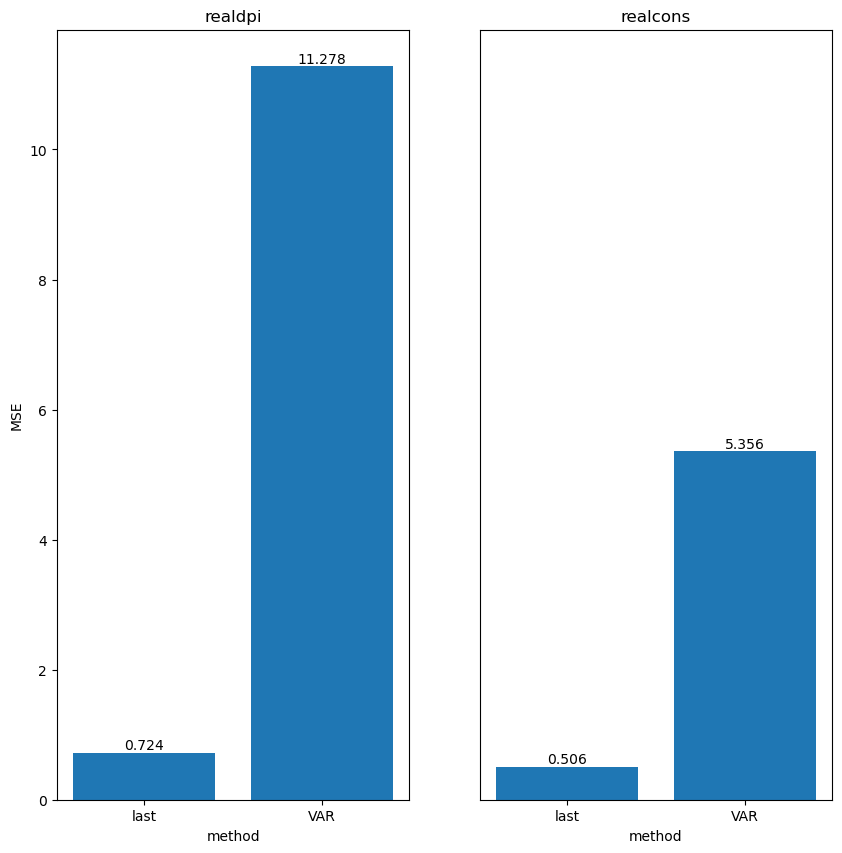

In [106]:
fig, ax = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10,10))
bars = ax[0].bar(mape_realdpi.index, mape_realdpi.values)
ax[0].bar_label(bars, fmt='%.3f')
ax[0].set_title('realdpi')
ax[0].set_xlabel('method')
ax[0].set_ylabel('MSE')

bars = ax[1].bar(mape_realcons.index, mape_realcons.values)
ax[1].bar_label(bars, fmt='%.3f')
ax[1].set_title('realcons')
ax[1].set_xlabel('method')
ax[1].yaxis.set_ticks_position('none')
ax[1].set_title('realcons')

plt.show()